<a href="https://colab.research.google.com/github/VishalB210/Carisurg_Week_0_Portfolio/blob/main/05_Assignment3_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving EmergencyTriageDataset_Reduced_Dirty.csv to EmergencyTriageDataset_Reduced_Dirty (6).csv
Dataset loaded successfully.

   ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR   Fio2
0   1   34       0  15.0   93   67.0   75.67  128.0  36.8  14.0   21.0
1   2   20    Male  15.0  130   90.0  103.33   80.0  37.0  16.0   21.0
2   3   77  Female  14.0  163  105.0  124.33   92.0  36.8  18.0   21.0
3   4   23       0   8.0  100   60.0   73.33  100.0  37.0  12.0  100.0
4   5   86  FEMALE  15.0  150   90.0  110.00   85.0  37.0  19.0   21.0

Pulse column cleaned for visualization.
Pulse median used: 90.0
Pulse missing values after cleaning: 0


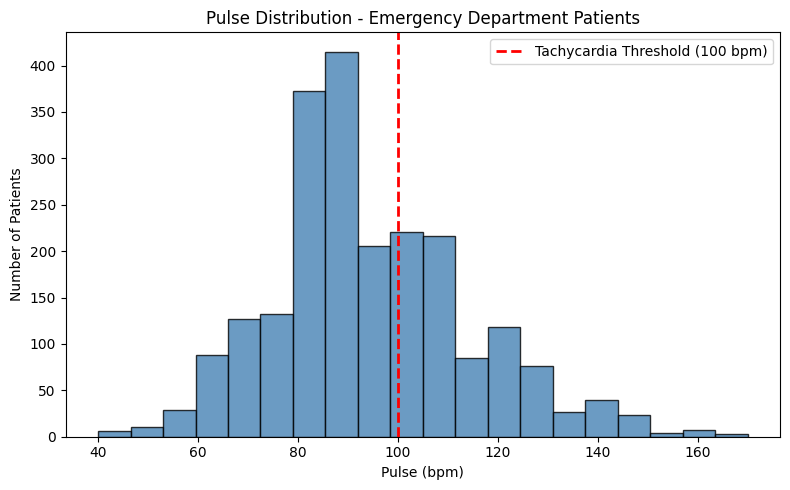

Saved: pulse_histogram.png


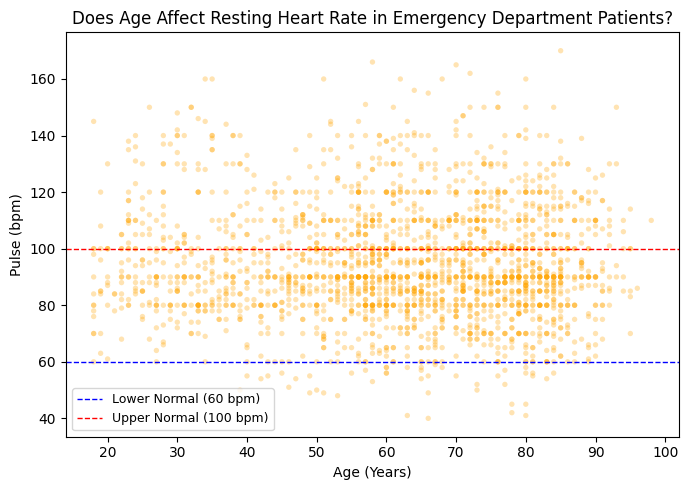

Saved: age_vs_pulse.png
Dataset Shape:
(2205, 11)

Missing Values:
ID         0
Age        0
Gender     0
GCS       22
SBP        0
DBP       22
MAP       22
pulse      0
Temp      22
RR        22
Fio2      22
dtype: int64

Pulse Summary Statistics:
count    2205.000000
mean       94.326984
std        19.881720
min        40.000000
25%        80.000000
50%        90.000000
75%       106.000000
max       170.000000
Name: pulse, dtype: float64


In [6]:
# Assignment 3 - Data Visualization

# STUDENT CHALLENGE QUESTIONS

# 1. What clinical question does this plot answer?

# Histogram:
# How are pulse rates distributed among Emergency Department patients?

# Scatter Plot:
# Does age affect resting heart rate in Emergency Department patients?

# 2. What type of plot is appropriate?

# Histogram for Pulse Distribution
# Scatter Plot for Age vs Pulse

# 3. What reference lines or annotations add clinical meaning?

# Histogram:
# Tachycardia Threshold = 100 bpm

# Scatter Plot:
# Lower Normal Pulse = 60 bpm
# Upper Normal Pulse = 100 bpm

# Objective

# The objective of this assignment is to perform data visualization on the Emergency Triage Dataset using Python and Matplotlib.

# For this assignment, I selected the Pulse column because heart rate is an important vital sign used in emergency medicine to assess circulation and patient stability.

# The Pulse column was previously cleaned and validated during Assignment 2 before being used for visualization.

# Two visualizations were created:

# 1. Histogram of Pulse Distribution
# 2. Scatter Plot of Age vs Pulse

# Import libraries

# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload dataset

uploaded = files.upload()

# Automatically read uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset loaded successfully.\n")
print(df.head())

# Clean Pulse again before visualization
df["pulse"] = pd.to_numeric(df["pulse"], errors="coerce")

# Replace unrealistic pulse values with NaN
df.loc[(df["pulse"] < 40) | (df["pulse"] > 170), "pulse"] = np.nan

# Fill missing pulse values with median
pulse_median = df["pulse"].median()
df["pulse"] = df["pulse"].fillna(pulse_median)

print("\nPulse column cleaned for visualization.")
print("Pulse median used:", pulse_median)
print("Pulse missing values after cleaning:", df["pulse"].isna().sum())
## Histogram - Pulse Distribution

# Clinical Question:

# How are pulse rates distributed among Emergency Department patients?

# Plot Type:

# Histogram

# Reason:

# Pulse is a numerical variable, so a histogram is useful for showing how pulse values are distributed across the dataset.

# Clinical Reference Line:

# A reference line was added at 100 bpm because pulse values above 100 bpm may indicate tachycardia.


# Histogram: Pulse Distribution

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df["pulse"],
    bins=20,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

# Clinical reference line for tachycardia

ax.axvline(
    x=100,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Tachycardia Threshold (100 bpm)"
)

ax.set_title(
    "Pulse Distribution - Emergency Department Patients",
    fontsize=12
)

ax.set_xlabel("Pulse (bpm)")
ax.set_ylabel("Number of Patients")

ax.legend()

plt.tight_layout()

plt.savefig(
    "pulse_histogram.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

print("Saved: pulse_histogram.png")


## Scatter Plot - Age vs Pulse

# Clinical Question:

# Does age affect resting heart rate in Emergency Department patients?

# Plot Type:

# Scatter Plot

# Reason:

# Both Age and Pulse are numerical variables. A scatter plot helps show whether there is a visible relationship between patient age and pulse rate.

# Clinical Reference Lines:

# Reference lines were added at 60 bpm and 100 bpm to represent the approximate normal resting heart rate range.


# Scatter Plot: Age vs Pulse

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    df["Age"],
    df["pulse"],
    alpha=0.3,
    s=15,
    color="orange",
    edgecolors="none"
)

# Clinical reference lines

ax.axhline(
    y=60,
    color="blue",
    linestyle="--",
    linewidth=1,
    label="Lower Normal (60 bpm)"
)

ax.axhline(
    y=100,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Upper Normal (100 bpm)"
)

ax.set_title(
    "Does Age Affect Resting Heart Rate in Emergency Department Patients?",
    fontsize=12
)

ax.set_xlabel("Age (Years)")
ax.set_ylabel("Pulse (bpm)")

ax.legend(fontsize=9)

plt.tight_layout()

plt.savefig(
    "age_vs_pulse.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

print("Saved: age_vs_pulse.png")


## Interpretation of Results

### Histogram Interpretation

# The histogram shows that most patients have pulse rates between approximately 80 and 100 bpm. A clinical reference line was included at 100 bpm to identify patients whose pulse may fall within the tachycardia range.

# Some patients had pulse values above 100 bpm, which may indicate physiological stress, infection, dehydration, pain, anxiety, or cardiovascular concerns.

### Scatter Plot Interpretation

# The scatter plot compares Age and Pulse. Pulse values are spread across different age groups, but there does not appear to be a strong relationship between age and pulse in this dataset.

# This suggests that other clinical factors may have a stronger influence on heart rate than age alone.


# Final validation and summary

print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nPulse Summary Statistics:")
print(df["pulse"].describe())


## Conclusion

# The Pulse column was visualized using a histogram and scatter plot.

# The histogram helped show the overall distribution of pulse values and highlighted patients above the tachycardia threshold of 100 bpm.

# The scatter plot was used to explore the relationship between Age and Pulse and showed no strong visible age-related trend.

# These visualizations show how cleaned clinical data can be used to identify patterns, abnormal values, and useful healthcare insights.


